In [6]:
from kan import KAN
import torch
from torch.utils.data import DataLoader, TensorDataset
from MLP2layers import NeuralNetwork, test_loop, train_loop

In [7]:
device = 'cpu'
model = NeuralNetwork().to(device)
print(model)
print(model.state_dict())
layers = list(*model.children())
print(list(*model.children()))
# print([(layer.weight, layer.bias) for layer in layers if isinstance(layer, torch.nn.Linear)])
# print(layers[0].weight.data)
# print(layers[0].weight)
# y = layers[0].weight[:,0]*10 + layers[0].bias*1
# print(y, y.shape)
x = torch.randn(10, 2)
print(layers[:1])
print(layers[1:])

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=2, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=1, bias=True)
  )
)
OrderedDict({'linear_relu_stack.0.weight': tensor([[-0.3091,  0.4082],
        [ 0.1265,  0.3591],
        [-0.4310, -0.7000]]), 'linear_relu_stack.0.bias': tensor([-0.2732, -0.5424,  0.5802]), 'linear_relu_stack.2.weight': tensor([[0.1663, 0.2391, 0.1826]]), 'linear_relu_stack.2.bias': tensor([-0.0100])})
[Linear(in_features=2, out_features=3, bias=True), ReLU(), Linear(in_features=3, out_features=1, bias=True)]
[Linear(in_features=2, out_features=3, bias=True)]
[ReLU(), Linear(in_features=3, out_features=1, bias=True)]


In [8]:
kan = KAN(width=[2,3,1], seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [9]:
kan.set_splines(x, modelPartitions=[layers[:1], layers[1:]])

weight.shape torch.Size([3])
bias.shape torch.Size([3])
scaled_base.shape torch.Size([2, 3])
scaled_base.shape torch.Size([10, 3])
base.shape torch.Size([10, 1])
y_spline.shape torch.Size([10, 3])
scale_sp.shape torch.Size([2, 3])
weight.shape torch.Size([3])
bias.shape torch.Size([3])
scaled_base.shape torch.Size([2, 3])
scaled_base.shape torch.Size([10, 3])
base.shape torch.Size([10, 1])
y_spline.shape torch.Size([10, 3])
scale_sp.shape torch.Size([2, 3])
y.shape torch.Size([10, 2, 3])
y tensor([[[ 0.0531, -0.8806,  1.2488],
         [-0.7624, -0.8159,  0.9110]],

        [[-0.0360, -0.8549,  1.1358],
         [-0.6380, -0.7328,  0.7831]],

        [[-0.0782, -0.8402,  1.0795],
         [-0.5804, -0.6979,  0.7357]],

        [[-0.1636, -0.8006,  0.9557],
         [-0.4962, -0.6507,  0.6781]],

        [[-0.2722, -0.5385,  0.5771],
         [-0.1555, -0.4929,  0.5535]],

        [[-0.2219, -0.4085,  0.4902],
         [-0.1442, -0.4884,  0.5516]],

        [[-0.2155, -0.3959,  0.4832],

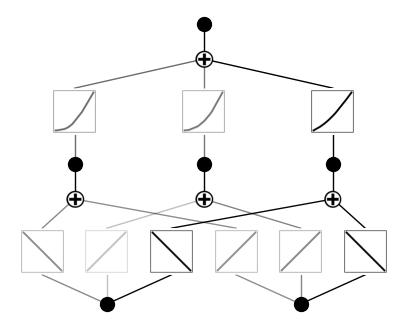

In [10]:
kan.plot()